In [1]:
# Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.metrics import (accuracy_score, f1_score,
                             classification_report,
                             ConfusionMatrixDisplay,
                             confusion_matrix)
import joblib

print("All imports successful!")

All imports successful!


Load Preprocessed Data

In [2]:
path = '/content/drive/MyDrive/CSE572_Project/'

train_df = pd.read_csv(path + 'train.csv')
val_df   = pd.read_csv(path + 'val.csv')
test_df  = pd.read_csv(path + 'test.csv')
classes  = np.load(path + 'label_classes.npy', allow_pickle=True)

X_train, y_train = train_df['text'], train_df['label']
X_val,   y_val   = val_df['text'],   val_df['label']
X_test,  y_test  = test_df['text'],  test_df['label']

print(f"Train: {len(X_train)} | Val: {len(X_val)} | Test: {len(X_test)}")
print(f"Classes: {list(classes)}")

Train: 1738 | Val: 373 | Test: 373
Classes: ['ACCOUNTANT', 'ADVOCATE', 'AGRICULTURE', 'APPAREL', 'ARTS', 'AUTOMOBILE', 'AVIATION', 'BANKING', 'BPO', 'BUSINESS-DEVELOPMENT', 'CHEF', 'CONSTRUCTION', 'CONSULTANT', 'DESIGNER', 'DIGITAL-MEDIA', 'ENGINEERING', 'FINANCE', 'FITNESS', 'HEALTHCARE', 'HR', 'INFORMATION-TECHNOLOGY', 'PUBLIC-RELATIONS', 'SALES', 'TEACHER']


In [3]:
# TF-IDF Vectorizer
tfidf = TfidfVectorizer(
    ngram_range=(1, 2),
    max_features=10000,
    sublinear_tf=True
)

# Filling NaN values with empty strings before vectorisation
X_train_tfidf = tfidf.fit_transform(X_train.fillna(''))
X_val_tfidf   = tfidf.transform(X_val.fillna(''))
X_test_tfidf  = tfidf.transform(X_test.fillna(''))

print(f"TF-IDF matrix shape (train): {X_train_tfidf.shape}")
print(f"TF-IDF matrix shape (val):   {X_val_tfidf.shape}")
print(f"TF-IDF matrix shape (test):  {X_test_tfidf.shape}")

TF-IDF matrix shape (train): (1738, 10000)
TF-IDF matrix shape (val):   (373, 10000)
TF-IDF matrix shape (test):  (373, 10000)


Logistic Regression

In [4]:
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train_tfidf, y_train)

lr_val_preds = lr.predict(X_val_tfidf)

print("=== Logistic Regression (Validation) ===")
print(f"Accuracy:    {accuracy_score(y_val, lr_val_preds):.4f}")
print(f"Macro F1:    {f1_score(y_val, lr_val_preds, average='macro'):.4f}")
print(f"Weighted F1: {f1_score(y_val, lr_val_preds, average='weighted'):.4f}")

=== Logistic Regression (Validation) ===
Accuracy:    0.6220
Macro F1:    0.5601
Weighted F1: 0.6050


Linear SVC

In [5]:
svm = LinearSVC(max_iter=2000, random_state=42)
svm.fit(X_train_tfidf, y_train)

svm_val_preds = svm.predict(X_val_tfidf)

print("=== Linear SVC (Validation) ===")
print(f"Accuracy:    {accuracy_score(y_val, svm_val_preds):.4f}")
print(f"Macro F1:    {f1_score(y_val, svm_val_preds, average='macro'):.4f}")
print(f"Weighted F1: {f1_score(y_val, svm_val_preds, average='weighted'):.4f}")
print("\nPer-class report:")
print(classification_report(y_val, svm_val_preds, target_names=classes))

=== Linear SVC (Validation) ===
Accuracy:    0.6729
Macro F1:    0.6299
Weighted F1: 0.6631

Per-class report:
                        precision    recall  f1-score   support

            ACCOUNTANT       0.88      0.78      0.82        18
              ADVOCATE       0.38      0.33      0.35        18
           AGRICULTURE       0.50      0.22      0.31         9
               APPAREL       0.57      0.53      0.55        15
                  ARTS       0.67      0.40      0.50        15
            AUTOMOBILE       0.75      0.50      0.60         6
              AVIATION       0.86      0.71      0.77        17
               BANKING       0.75      0.71      0.73        17
                   BPO       0.00      0.00      0.00         3
  BUSINESS-DEVELOPMENT       0.62      0.83      0.71        18
                  CHEF       0.82      0.78      0.80        18
          CONSTRUCTION       0.72      0.76      0.74        17
            CONSULTANT       0.60      0.35      0.44   

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Confusion Matrix

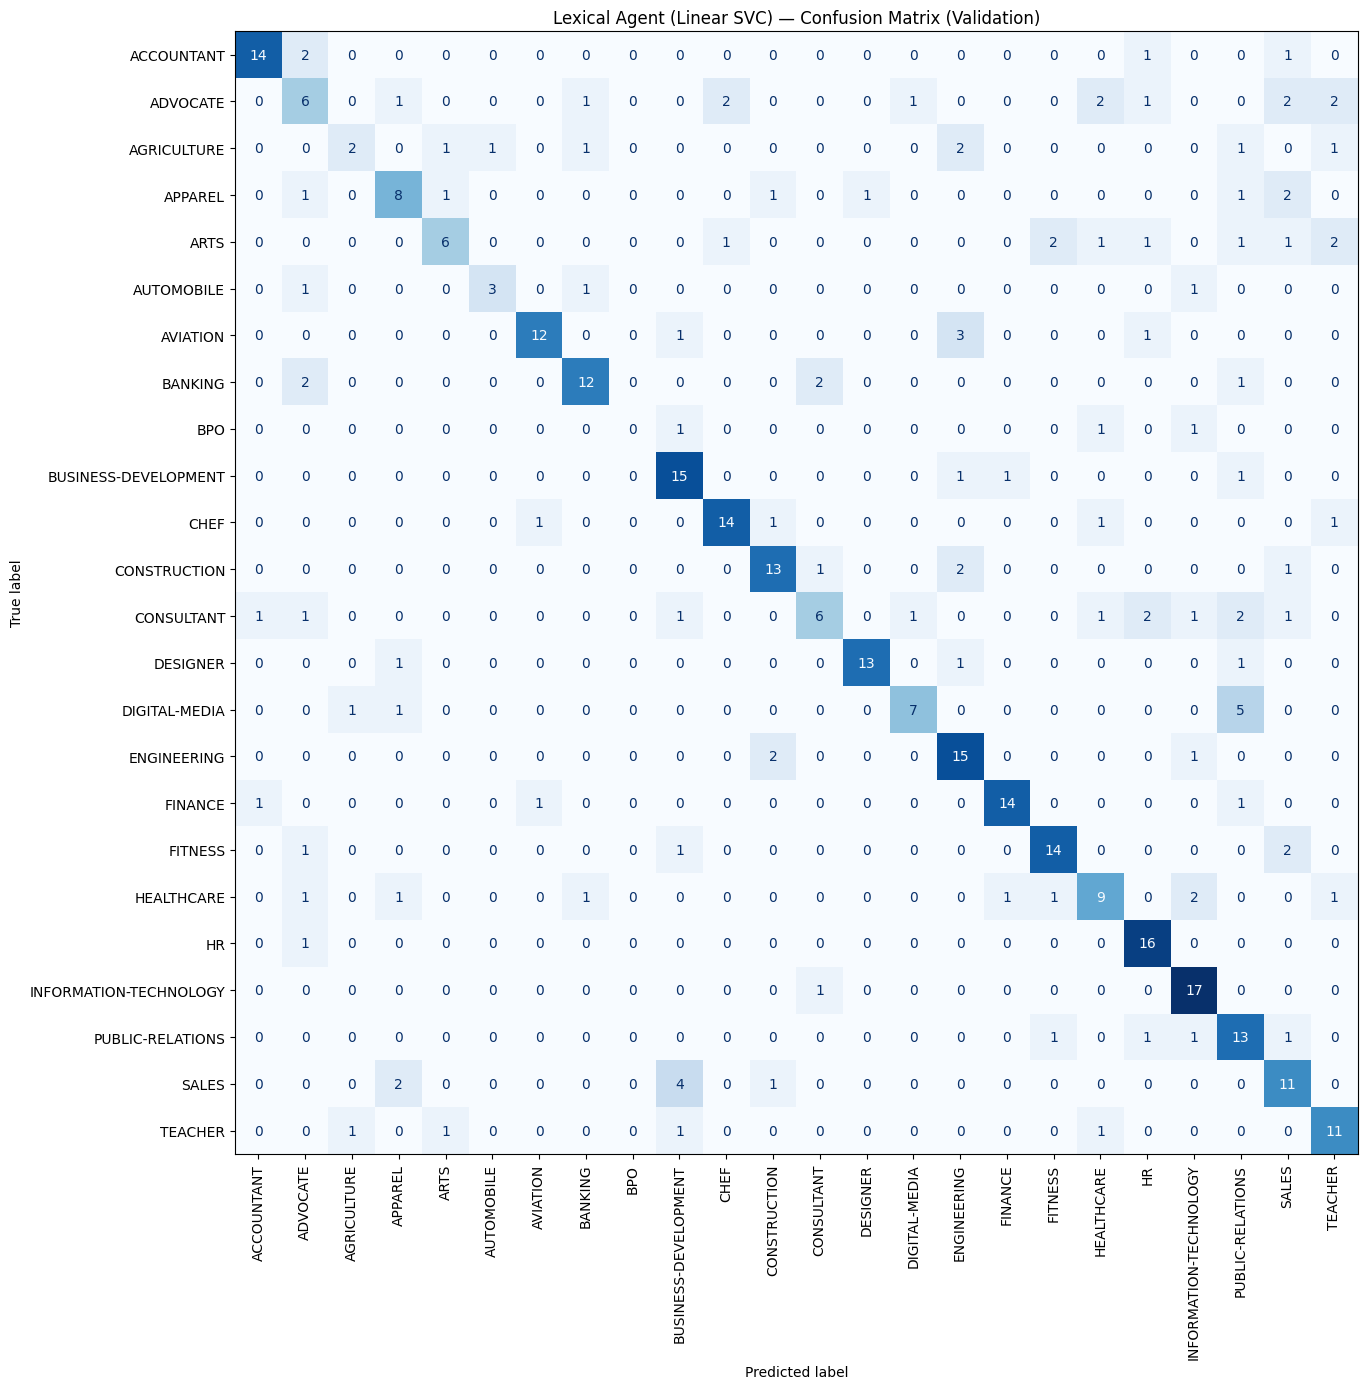

In [6]:
fig, ax = plt.subplots(figsize=(16, 14))
cm = confusion_matrix(y_val, svm_val_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                               display_labels=classes)
disp.plot(ax=ax, xticks_rotation=90, colorbar=False, cmap='Blues')
ax.set_title('Lexical Agent (Linear SVC) — Confusion Matrix (Validation)')
plt.tight_layout()
plt.savefig(path + 'lexical_confusion_matrix.png', dpi=150)
plt.show()

In [7]:
# Final Test Evaluation & Save
svm_test_preds = svm.predict(X_test_tfidf)

print("=== Linear SVC (Test Set - Final) ===")
print(f"Accuracy:    {accuracy_score(y_test, svm_test_preds):.4f}")
print(f"Macro F1:    {f1_score(y_test, svm_test_preds, average='macro'):.4f}")
print(f"Weighted F1: {f1_score(y_test, svm_test_preds, average='weighted'):.4f}")

# Save model and vectorizer
joblib.dump(svm,   path + 'lexical_svm.pkl')
joblib.dump(tfidf, path + 'lexical_tfidf.pkl')

# Save probability-style outputs for fusion agent later
# LinearSVC doesn't give probabilities, so we save decision function scores
train_scores = svm.decision_function(X_train_tfidf)
val_scores   = svm.decision_function(X_val_tfidf)
test_scores  = svm.decision_function(X_test_tfidf)

np.save(path + 'lexical_train_scores.npy', train_scores)
np.save(path + 'lexical_val_scores.npy',   val_scores)
np.save(path + 'lexical_test_scores.npy',  test_scores)

print("\nSaved:")
print("  lexical_svm.pkl")
print("  lexical_tfidf.pkl")
print("  lexical_train/val/test_scores.npy")

=== Linear SVC (Test Set - Final) ===
Accuracy:    0.7292
Macro F1:    0.6721
Weighted F1: 0.7099

Saved:
  lexical_svm.pkl
  lexical_tfidf.pkl
  lexical_train/val/test_scores.npy
